In [172]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.metrics import accuracy_score, classification_report


In [173]:
df = pd.read_csv('dataset.csv')
df.head()

df = df.drop('id', axis=1)

In [174]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             391 non-null    float64
 1   bp              388 non-null    float64
 2   sg              353 non-null    float64
 3   al              354 non-null    float64
 4   su              351 non-null    float64
 5   rbc             248 non-null    str    
 6   pc              335 non-null    str    
 7   pcc             396 non-null    str    
 8   ba              396 non-null    str    
 9   bgr             356 non-null    float64
 10  bu              381 non-null    float64
 11  sc              383 non-null    float64
 12  sod             313 non-null    float64
 13  pot             312 non-null    float64
 14  hemo            348 non-null    float64
 15  pcv             330 non-null    str    
 16  wc              295 non-null    str    
 17  rc              270 non-null    str    
 18  h

In [175]:
for col in df.select_dtypes(include="object"):
    df[col] = df[col].str.strip()


/tmp/ipykernel_6948/1160752383.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object"):


In [176]:
df = df.replace('?', np.nan)

In [177]:
for col in df.columns:
    
    print(col)
    print(df[col].unique())
    print('======================================================================')

age
[48.  7. 62. 51. 60. 68. 24. 52. 53. 50. 63. 40. 47. 61. 21. 42. 75. 69.
 nan 73. 70. 65. 76. 72. 82. 46. 45. 35. 54. 11. 59. 67. 15. 55. 44. 26.
 64. 56.  5. 74. 38. 58. 71. 34. 17. 12. 43. 41. 57.  8. 39. 66. 81. 14.
 27. 83. 30.  4.  3.  6. 32. 80. 49. 90. 78. 19.  2. 33. 36. 37. 23. 25.
 20. 29. 28. 22. 79.]
bp
[ 80.  50.  70.  90.  nan 100.  60. 110. 140. 180. 120.]
sg
[1.02  1.01  1.005 1.015   nan 1.025]
al
[ 1.  4.  2.  3.  0. nan  5.]
su
[ 0.  3.  4.  1. nan  2.  5.]
rbc
<StringArray>
[nan, 'normal', 'abnormal']
Length: 3, dtype: str
pc
<StringArray>
['normal', 'abnormal', nan]
Length: 3, dtype: str
pcc
<StringArray>
['notpresent', 'present', nan]
Length: 3, dtype: str
ba
<StringArray>
['notpresent', 'present', nan]
Length: 3, dtype: str
bgr
[121.  nan 423. 117. 106.  74. 100. 410. 138.  70. 490. 380. 208.  98.
 157.  76.  99. 114. 263. 173.  95. 108. 156. 264. 123.  93. 107. 159.
 140. 171. 270.  92. 137. 204.  79. 207. 124. 144.  91. 162. 246. 253.
 141. 182.  86. 150. 1

In [178]:
cols = ['pcv','wc','rc']

for c in cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')


In [179]:
for col in df.columns:

    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].mean())

    else:
        df[col] = df[col].fillna(df[col].mode()[0])
        
df = pd.get_dummies(df, drop_first=True)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    400 non-null    float64
 1   bp                     400 non-null    float64
 2   sg                     400 non-null    float64
 3   al                     400 non-null    float64
 4   su                     400 non-null    float64
 5   bgr                    400 non-null    float64
 6   bu                     400 non-null    float64
 7   sc                     400 non-null    float64
 8   sod                    400 non-null    float64
 9   pot                    400 non-null    float64
 10  hemo                   400 non-null    float64
 11  pcv                    400 non-null    float64
 12  wc                     400 non-null    float64
 13  rc                     400 non-null    float64
 14  rbc_normal             400 non-null    bool   
 15  pc_normal        

classification_notckd
False    250
True     150
Name: count, dtype: int64

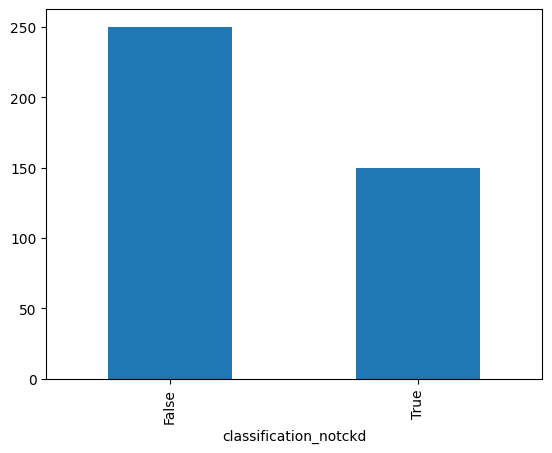

In [180]:
df['classification_notckd'].value_counts().plot(kind='bar')

df['classification_notckd'].value_counts()

In [181]:
x = df.drop('classification_notckd', axis=1)
y = df['classification_notckd']

In [182]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [183]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scale', StandardScaler()),
    ('model', svm.SVC(kernel='rbf'))
])


pipeline.fit(x_train, y_train)

y_pred = pipeline.predict(x_test)

In [184]:
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


0.9875
              precision    recall  f1-score   support

       False       1.00      0.98      0.99        52
        True       0.97      1.00      0.98        28

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



In [185]:
for col in df.columns:
    if pd.api.types.is_bool_dtype(df[col]):
        print(f"{col} 0/1:")

rbc_normal 0/1:
pc_normal 0/1:
pcc_present 0/1:
ba_present 0/1:
htn_yes 0/1:
dm_yes 0/1:
cad_yes 0/1:
appet_poor 0/1:
pe_yes 0/1:
ane_yes 0/1:
classification_notckd 0/1:
